In [1]:
# https://github.com/MedVisBonn/eyepy
# TODO: test e2e readability in python
!pip install eyepy


   ---------------------------------------- 0/3 [construct]
   ------------- -------------------------- 1/3 [construct-typing]
   -------------------------- ------------- 2/3 [eyepy]
   -------------------------- ------------- 2/3 [eyepy]
   -------------------------- ------------- 2/3 [eyepy]
   ---------------------------------------- 3/3 [eyepy]



In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import eyepy as ep

DATA_DIR = Path("../data/heyex")

e2e_files = sorted(DATA_DIR.glob("*.e2e")) + sorted(DATA_DIR.glob("*.E2E"))

print("E2E files found:", len(e2e_files))
for f in e2e_files:
    print(f.name, f.stat().st_size / 1e6, "MB")

E2E files found: 2
EA010.E2E 53.359328 MB
EA010.E2E 53.359328 MB


In [3]:
e2e_path = e2e_files[0]

ev = ep.import_heyex_e2e(e2e_path)

print(type(ev))
print(ev)

<class 'eyepy.core.eyevolume.EyeVolume'>


In [4]:
attrs = [a for a in dir(ev) if not a.startswith("_")]
attrs

['add_layer_annotation',
 'add_pixel_annotation',
 'add_slab_annotation',
 'data',
 'data_par',
 'intensity_transform',
 'laterality',
 'layers',
 'load',
 'localizer',
 'localizer_transform',
 'meta',
 'par_algorithm',
 'plot',
 'remove_layer_annotation',
 'remove_pixel_annotation',
 'remove_slab_annotation',
 'save',
 'scale',
 'scale_unit',
 'scale_x',
 'scale_y',
 'scale_z',
 'set_intensity_transform',
 'set_par_algorithm',
 'shape',
 'size_x',
 'size_y',
 'size_z',
 'slabs',
 'volume_maps']

In [ ]:
ev.plot()

In [6]:
print("Has data:", hasattr(ev, "data"))

Has data: True


In [7]:
print("Has volume:", hasattr(ev, "volume"))

Has volume: False


In [8]:
print("Has layers:", hasattr(ev, "layers"))

Has layers: True


In [9]:
print("Has meta:", hasattr(ev, "meta"))

Has meta: True


In [10]:
if hasattr(ev, "data"):
    print(type(ev.data))
    try:
        print(ev.data.shape)
    except Exception as e:
        print(e)

<class 'numpy.ndarray'>
(97, 496, 512)


In [11]:
if hasattr(ev, "layers"):
    print(type(ev.layers))
    print(ev.layers)

<class 'dict'>
{'ILM': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F1759ECEC0>, 'BM': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F175833890>, 'RNFL': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F1758339D0>, 'GCL': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F175A16190>, 'IPL': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F175A162C0>, 'INL': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F1759CCB90>, 'OPL': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F17582B130>, 'ELM': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F17582B240>, 'PR1': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F175934E50>, 'PR2': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F175934F50>, 'RPE': <eyepy.core.annotations.EyeVolumeLayerAnnotation object at 0x000001F175885220>}


In [12]:
for a in attrs:
    if "layer" in a.lower() or "seg" in a.lower():
        print(a)

add_layer_annotation
layers
remove_layer_annotation


In [15]:
print("shape:", ev.shape)
print("scale:", ev.scale)
print("scale_unit:", ev.scale_unit)
print("scale_x:", ev.scale_x)
print("scale_y:", ev.scale_y)
print("scale_z:", ev.scale_z)
print("laterality:", ev.laterality)
print("meta:", ev.meta)

shape: (97, 496, 512)
scale: (1, 1, 1)
scale_unit: px
scale_x: 1
scale_y: 1
scale_z: 1
laterality: 82
meta: scale_z: 1
scale_x: 1
scale_y: 1
scale_unit: px
bscan_meta: [start_pos: (-10.0, 10.0)
end_pos: (10.0, 10.0)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -10.0
start_y: 10.0
end_x: 10.0
end_y: 10.0
zero1: 0
unknown1: 542867328.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    7143.47607421875
    109.4543228149414
zero3: 0
imgSizeWidth: 512
n_bscans: 97
aktImage: 0
scan_pattern: 1
center_x: 0.0
center_y: 10.0
unknown4: 1
acquisitionTime: 2023-10-24T20:11:00.170000
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728, start_pos: (-10.0, 9.791666984558105)
end_pos: (10.0, 9.791666984558105)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -10.0
start_y: 9.791666984558105
end_x: 10.0
end_y: 9.791666984558105
zero1: 0
unknown1: 518653664.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContain

In [16]:
rpe = ev.layers["RPE"].data
bm = ev.layers["BM"].data
ilm = ev.layers["ILM"].data

print("RPE shape:", rpe.shape)
print("BM shape:", bm.shape)
print("ILM shape:", ilm.shape)
print("RPE range:", np.nanmin(rpe), np.nanmax(rpe))
print("BM range:", np.nanmin(bm), np.nanmax(bm))

RPE shape: (97, 512)
BM shape: (97, 512)
ILM shape: (97, 512)
RPE range: 94.97542572021484 212.9291534423828
BM range: 97.87492370605469 216.0696563720703


In [ ]:
bidx = 42

bscan = ev.data[bidx]
rpe_b = rpe[bidx]
bm_b = bm[bidx]
ilm_b = ilm[bidx]

x = np.arange(bscan.shape[1])

plt.figure(figsize=(12, 6))
plt.imshow(bscan, cmap="gray")

plt.plot(x, ilm_b, label="ILM")
plt.plot(x, rpe_b, label="RPE")
plt.plot(x, bm_b, label="BM")

plt.title(f"B-scan {bidx+1}/{ev.data.shape[0]} with HEYEX segmentation layers")
plt.legend()
plt.axis("off")
plt.show()

## E2E Import Check

The exported HEYEX `.E2E` file was successfully loaded using `eyepy`.

The file contains:

- 97 OCT B-scans
- Each B-scan has shape 496 × 512
- HEYEX segmentation layers are available
- RPE and BM boundaries are accessible as arrays of shape 97 × 512
- Segmentation overlays are visually consistent with HEYEX

This confirms that the exported E2E files preserve the core information needed for RPE-based flattening, ROI extraction, and future barcoding quantification.

In [ ]:
bidx = 42

bscan = ev.data[bidx].astype(float)
rpe_b = ev.layers["RPE"].data[bidx]

target_y = int(np.nanmedian(rpe_b))

flattened = np.zeros_like(bscan)

for x in range(bscan.shape[1]):
    shift = int(target_y - rpe_b[x])
    flattened[:, x] = np.roll(bscan[:, x], shift)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(bscan, cmap="gray")
plt.plot(np.arange(bscan.shape[1]), rpe_b, label="RPE")
plt.title("Original B-scan")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flattened, cmap="gray")
plt.axhline(target_y, linestyle="--", label="Flattened RPE")
plt.title("RPE-Flattened B-scan")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Check several slices
for bidx in [24, 42, 60]:
    bscan = ev.data[bidx].astype(float)
    rpe_b = ev.layers["RPE"].data[bidx]

    target_y = int(np.nanmedian(rpe_b))
    flattened = np.zeros_like(bscan)

    for x in range(bscan.shape[1]):
        shift = int(target_y - rpe_b[x])
        flattened[:, x] = np.roll(bscan[:, x], shift)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(bscan, cmap="gray")
    plt.plot(np.arange(bscan.shape[1]), rpe_b)
    plt.title(f"Original B-scan {bidx}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(flattened, cmap="gray")
    plt.axhline(target_y, linestyle="--")
    plt.title("RPE-flattened")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

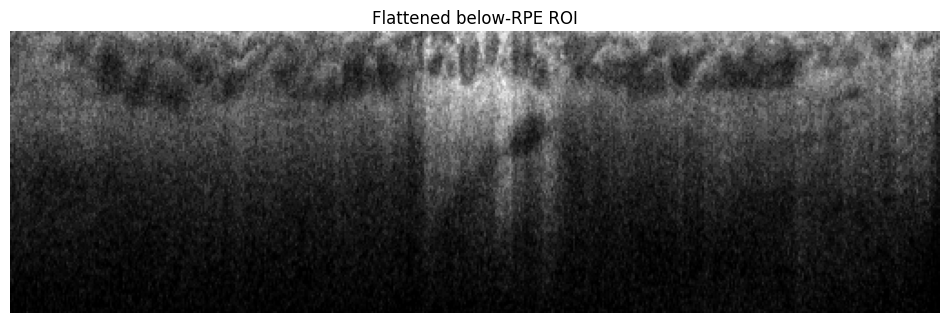

In [20]:
bidx = 42

bscan = ev.data[bidx].astype(float)
rpe_b = ev.layers["RPE"].data[bidx]
target_y = int(np.nanmedian(rpe_b))

flattened = np.zeros_like(bscan)

for x in range(bscan.shape[1]):
    shift = int(target_y - rpe_b[x])
    flattened[:, x] = np.roll(bscan[:, x], shift)

roi_top = target_y + 5
roi_bottom = target_y + 160

choroid_roi = flattened[roi_top:roi_bottom, :]

plt.figure(figsize=(12, 4))
plt.imshow(choroid_roi, cmap="gray")
plt.title("Flattened below-RPE ROI")
plt.axis("off")
plt.show()

In [21]:
rpe = ev.layers["RPE"].data[bidx]

print("Original")
print("std =", np.std(rpe))
print("range =", np.ptp(rpe))

Original
std = 6.764010809297561
range = 23.810447692871094


In [22]:
target_y = int(np.nanmedian(rpe))

rpe_flat = np.full_like(rpe, target_y)

print("Flattened")
print("std =", np.std(rpe_flat))
print("range =", np.ptp(rpe_flat))
print(choroid_roi.shape)

Flattened
std = 0.0
range = 0.0
(155, 512)


In [23]:
print(np.mean(bscan))
print(np.mean(flattened))

print(np.std(bscan))
print(np.std(flattened))

24.413274949596776
24.413274949596776
37.51761116029925
37.51761116029925


In [24]:
rpe = ev.layers["RPE"].data[bidx]
bm = ev.layers["BM"].data[bidx]

print("Original RPE std:", np.std(rpe))
print("Original BM std:", np.std(bm))

Original RPE std: 6.764010809297561
Original BM std: 7.002058027410318


In [25]:
bm_flat = np.empty_like(bm)

for x in range(len(bm)):
    shift = target_y - rpe[x]
    bm_flat[x] = bm[x] + shift

print("Flattened BM std:", np.std(bm_flat))

Flattened BM std: 1.6897566321222128
